# CatBoost — Optuna Hyperparameter Tuning (GPU)

Same data pipeline / CV / sample_weight as `catboost.ipynb`. Searches CatBoost-specific knobs: `depth`, `learning_rate`, `l2_leaf_reg`, `bagging_temperature`, `border_count`, `random_strength`, `min_data_in_leaf`.

**Goal:** push CatBoost single-OOF from 0.93130 (untuned) toward the GBMs' ~0.935 so the 3-way blend pays off on the LB (sub_28 LB underperformed because untuned CB was too weak even though OOF said the blend should win).

After this finishes, paste `study.best_params` into `catboost.ipynb` and re-run it — that produces the OOF/test CSVs `blender3.ipynb` consumes.

## Imports

In [1]:
import pandas as pd
import numpy as np
import warnings, json
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

import catboost as cb
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold

from common import *

print('catboost:', cb.__version__)
print('optuna:  ', optuna.__version__)

catboost: 1.2.10
optuna:   4.8.0


## Load + preprocess (mirror of catboost.ipynb)

In [2]:
train_df = pd.read_csv('archive/train.csv')
test_df  = pd.read_csv('archive/test.csv')
orig_df  = pd.read_csv('archive/f1_strategy_dataset_v4.csv')

df = (train_df.pipe(copy_data).pipe(clean_data).pipe(remove_duplicates).pipe(make_new_features))
orig_df_cleaned = (orig_df.pipe(copy_data).pipe(clean_data).pipe(remove_duplicates).pipe(make_new_features))

train_df_length = df.shape[0]
df = pd.concat([df, orig_df_cleaned])
if 'normalized_tyrelife' in df.columns:
    df = df.drop('normalized_tyrelife', axis=1)
df = df.reset_index(drop=True)

sample_weights = np.ones(df.shape[0])
sample_weights[train_df_length:] = 1.25

target = get_target()
features = get_features(df)
categorical_features = ['compound', 'race', 'year_cat']
for c in categorical_features:
    df[c] = df[c].astype(str).fillna('NA')

X, y = df[features], df[target]
groups = (df['race'].astype(str) + '_' + df['year'].astype(str)).values
strat_y = (df['pitnextlap'].astype(str) + '_' + df['year'].astype(str))

print(df.shape, '/', len(features), 'features')

(540511, 15) / 14 features


## Optuna objective — 5-fold StratifiedGroupKFold + early stopping

In [3]:
TUNE_N_SPLITS = 5
SEED = 42

def objective(trial):
    params = {
        'iterations': 5000,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'GPU',
        'devices': '0',
        'random_seed': 123,
        'verbose': 0,
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth':               trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 0.5, 30.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 2.0),
        'border_count':        trial.suggest_categorical('border_count', [64, 128, 254]),
        'random_strength':     trial.suggest_float('random_strength', 0.0, 5.0),
        'min_data_in_leaf':    trial.suggest_int('min_data_in_leaf', 1, 100),
    }

    sgkf = StratifiedGroupKFold(n_splits=TUNE_N_SPLITS, shuffle=True, random_state=123)
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X, strat_y, groups=groups)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = CatBoostClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            cat_features=categorical_features,
            sample_weight=sample_weights[tr_idx],
            early_stopping_rounds=50,
            verbose=0,
        )
        proba = model.predict_proba(X_val)[:, 1]
        fold_scores.append(roc_auc_score(y_val, proba))

        trial.report(float(np.mean(fold_scores)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))

## Run study

Enqueue the default-ish params as trial 0 to anchor the search.

In [4]:
N_TRIALS = 60
TIMEOUT_SEC = 60 * 60 * 5   # 5 hours cap

baseline_params = {
    'learning_rate':       0.05,
    'depth':               6,
    'l2_leaf_reg':         3.0,
    'bagging_temperature': 1.0,
    'border_count':        254,
    'random_strength':     1.0,
    'min_data_in_leaf':    1,
}

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
    study_name='catboost_f1_pit',
)
study.enqueue_trial(baseline_params)
study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT_SEC, show_progress_bar=True, gc_after_trial=True)

print('best AUC (5-fold):', round(study.best_value, 5))
print('best params:', study.best_params)

[I 2026-05-28 17:36:19,135] A new study created in memory with name: catboost_f1_pit


  0%|          | 0/60 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[I 2026-05-28 17:38:02,993] Trial 0 finished with value: 0.9247356344848893 and parameters: {'learning_rate': 0.05, 'depth': 6, 'l2_leaf_reg': 3.0, 'bagging_temperature': 1.0, 'border_count': 254, 'random_strength': 1.0, 'min_data_in_leaf': 1}. Best is trial 0 with value: 0.9247356344848893.


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


...

[I 2026-05-28 19:37:39,893] Trial 57 pruned. 


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[I 2026-05-28 19:40:17,343] Trial 58 finished with value: 0.9260437636104412 and parameters: {'learning_rate': 0.034614511708745695, 'depth': 8, 'l2_leaf_reg': 24.128666092228134, 'bagging_temperature': 0.6096553584020981, 'border_count': 254, 'random_strength': 3.3077837640892125, 'min_data_in_leaf': 93}. Best is trial 25 with value: 0.9266151140006554.


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[I 2026-05-28 19:40:50,035] Trial 59 pruned. 
best AUC (5-fold): 0.92662
best params: {'learning_rate': 0.06046142783199642, 'depth': 10, 'l2_leaf_reg': 10.403790011946096, 'bagging_temperature': 0.02594475248352794, 'border_count': 254, 'random_strength': 4.871050515345347, 'min_data_in_leaf': 26}


## Study summary

In [5]:
trials_df = study.trials_dataframe(attrs=('number', 'value', 'state', 'params', 'duration'))
trials_df = trials_df.sort_values('value', ascending=False)
trials_df.head(15)

,number,value,state,params_bagging_temperature,params_border_count,params_depth,params_l2_leaf_reg,params_learning_rate,params_min_data_in_leaf,params_random_strength,duration
59,59,0.926963,PRUNED,0.397098,128,6,2.110050,0.092439,84,4.370028,0 days 00:00:32.619252
48,48,0.926823,PRUNED,1.074745,254,5,2.634928,0.040932,83,4.133917,0 days 00:00:58.236811
46,46,0.926813,PRUNED,0.958168,64,6,18.989366,0.014624,67,3.962407,0 days 00:02:05.171271
42,42,0.926625,PRUNED,0.190038,128,10,4.408126,0.040927,29,4.420440,0 days 00:02:25.317073
25,25,0.926615,COMPLETE,0.025945,254,10,10.403790,0.060461,26,4.871051,0 days 00:03:23.748588
30,30,0.926535,PRUNED,0.705516,254,10,1.983424,0.042611,30,4.541014,0 days 00:02:12.434950
53,53,0.926507,PRUNED,0.418168,254,7,4.684725,0.018882,93,1.579455,0 days 00:01:21.252369
56,56,0.926450,PRUNED,0.894832,128,10,20.554767,0.032414,68,2.805593,0 days 00:02:54.710535
50,50,0.926392,COMPLETE,0.554200,254,8,10.861479,0.020872,81,3.423237,0 days 00:04:09.371457
44,44,0.926311,COMPLETE,0.721589,64,8,23.305396,0.019631,62,3.166832,0 days 00:05:04.740406


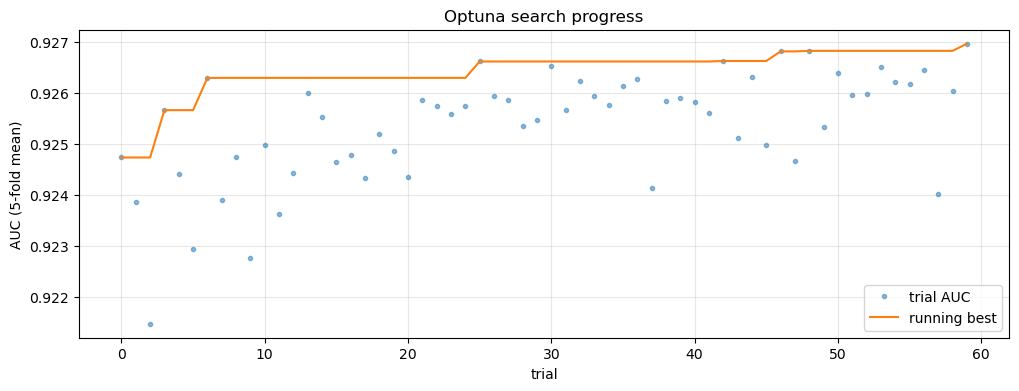

In [6]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.figsize'] = (12, 4)

vals = [t.value for t in study.trials if t.value is not None]
running_best = np.maximum.accumulate(vals)
plt.plot(vals, '.', alpha=0.5, label='trial AUC')
plt.plot(running_best, label='running best')
plt.xlabel('trial')
plt.ylabel('AUC (5-fold mean)')
plt.legend(); plt.grid(alpha=0.3); plt.title('Optuna search progress'); plt.show()

## Validate best params on the full 10-fold CV

Same splitter / seed as `catboost.ipynb` so the score is directly comparable. After this finishes, paste `study.best_params` into `catboost.ipynb` and re-run it — that produces the OOF/test CSVs the blender consumes.

In [7]:
best_params = {
    'iterations': 5000,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'task_type': 'GPU',
    'devices': '0',
    'random_seed': 123,
    'verbose': 0,
    **study.best_params,
}

sgkf_full = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=123)
scores, best_iters = [], []

for fold, (tr_idx, val_idx) in enumerate(sgkf_full.split(X, strat_y, groups=groups)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = CatBoostClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        cat_features=categorical_features,
        sample_weight=sample_weights[tr_idx],
        early_stopping_rounds=50,
        verbose=0,
    )
    proba = model.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, proba)
    scores.append(score)
    best_iters.append(model.best_iteration_)
    print(f'Fold {fold}: AUC={score:.5f}  best_iter={model.best_iteration_}')

print(f'\nMean AUC: {np.mean(scores):.5f} ± {np.std(scores):.5f}')
print(f'Mean best_iter: {int(np.mean(best_iters))}  Max best_iter: {int(np.max(best_iters))}')

Default metric period is 5 because AUC is/are not implemented for GPU


Fold 0: AUC=0.91606  best_iter=472


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 1: AUC=0.90265  best_iter=87


Default metric period is 5 because AUC is/are not implemented for GPU


...

Fold 7: AUC=0.92635  best_iter=606


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 8: AUC=0.93175  best_iter=834


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 9: AUC=0.91552  best_iter=175

Mean AUC: 0.92542 ± 0.01130
Mean best_iter: 434  Max best_iter: 834


In [8]:
with open('./archive/catboost_best_params.json', 'w') as f:
    json.dump({
        'best_params': study.best_params,
        'best_value_5fold': study.best_value,
        'mean_auc_10fold': float(np.mean(scores)),
        'std_auc_10fold':  float(np.std(scores)),
        'best_iters': [int(b) for b in best_iters],
    }, f, indent=2)
print('saved ./archive/catboost_best_params.json')

saved ./archive/catboost_best_params.json
